# Drill Down Hall 07

- As this notebook runs locally, please install the required packages first.
- Open a terminal and run: `pip install -r requirements.txt --no-index`
- Note: The results may differ slightly from those shown in the dashboard

In [44]:
import os
import duckdb
import pandas as pd
from minio_utils import (
    get_duckdb_s3_setup_sql,
)
import matplotlib.pyplot as plt

In [45]:
GOLD_BUCKET = os.environ.get("BUCKET_GOLD", "gold")
HALL_ID = 'H07'

In [46]:
def get_connection():
    """
    Create a DuckDB connection configured to read/write Parquet files
    directly from MinIO (S3-compatible storage).
    """
    con = duckdb.connect()
    con.execute(get_duckdb_s3_setup_sql())
    return con

con = get_connection()

In [47]:
fact_measurement_df = con.execute(f"""
    SELECT *
    FROM read_parquet('s3://{GOLD_BUCKET}/fact_measurement/data.parquet')
""").fetchdf()
print(f'{len(fact_measurement_df)}')

6762720


In [48]:
fact_measurement_df

,hall_id,meter_id,timestamp,value
0,H01,h01_z_1111_kombiwalzen_c2wc_z_a,2025-01-01 01:14:00+01:00,0.022728
1,H01,h01_z_1111_kombiwalzen_c2wc_z_a,2025-01-01 01:29:00+01:00,0.024451
2,H01,h01_z_1111_kombiwalzen_c2wc_z_a,2025-01-01 01:44:00+01:00,0.028263
3,H01,h01_z_1111_kombiwalzen_c2wc_z_a,2025-01-01 01:59:00+01:00,0.020389
4,H01,h01_z_1111_kombiwalzen_c2wc_z_a,2025-01-01 02:14:00+01:00,0.023487
...,...,...,...,...
6762715,NVP,nvp_z_1200_mshv_2_20kv_bergabe,2025-12-31 23:59:00+01:00,245.342750
6762716,NVP,nvp_z_1200_mshv_2_20kv_bergabe,2026-01-01 00:14:00+01:00,237.017500
6762717,NVP,nvp_z_1200_mshv_2_20kv_bergabe,2026-01-01 00:29:00+01:00,244.468453
6762718,NVP,nvp_z_1200_mshv_2_20kv_bergabe,2026-01-01 00:44:00+01:00,242.213000


In [49]:
dim_hall_df = con.execute(f"""
    SELECT *
    FROM read_parquet('s3://{GOLD_BUCKET}/dim_hall/data.parquet')
    ORDER BY hall_id
""").fetchdf()

print(len(dim_hall_df))
dim_hall_df

9


,hall_id,hall_label
0,H01,Hall H01
1,H02,Hall H02
2,H03,Hall H03
3,H04,Hall H04
4,H05,Hall H05
5,H06,Hall H06
6,H07,Hall H07
7,H08,Hall H08
8,NVP,Hall NVP


In [50]:
dim_meter = con.execute(f"""
    SELECT *
    FROM read_parquet('s3://{GOLD_BUCKET}/dim_meter/data.parquet')
    ORDER BY hall_id
""").fetchdf()

print(len(dim_meter))
dim_meter

193


,hall_id,meter_id,meter_name,meter_desc
0,H01,h01_z_1131_lades_ulen_poolfahrz,Z 1131 Ladesäulen Poolfahrzeuge,Ladesäulen firmeneigene Poolfahrzeuge
1,H01,h01_z_1129_beleuchtung_halle_1,Z 1129 Beleuchtung Halle 1 EG: Z-alt 217,Beleuchtung Halle 1 EG SK:1.1.1.2_F8
2,H01,h01_z_1116_bereich_reinigungskr,Z 1116 Bereich Reinigungskräfte,Stromschiene_5: 1.1.1.1/F6
3,H01,h01_z_1121_uv4_future_lab_z_alt,Z 1121 UV4 Future Lab: Z-alt 260,UV4 Halle SK:1.1.1.2_F1
4,H01,h01_z_1127_b_ro_eg_kantine,Z 1127 Büro EG + Kantine,Büro EG + Kantine SK:1.1.1.2_F9
...,...,...,...,...
188,H08,h08_z_1826_halle_8_waschmaschin,Z 1826 Halle 8 Waschmaschine 2,Anlage 2
189,H08,h08_z_1828_halle_8_uv_8_h1_eg_g,Z 1828 Halle 8 UV-8.H1_EG Gesamt,UV-8.H1 P1
190,H08,h08_z_1814_halle_8_isp10_lueftu,Z 1814 Halle 8 ISP10 Lueftung,ISP 10
191,H08,h08_z_1837_msr_vorwaschanlage,Z 1837 MSR Vorwaschanlage,MSR Pfänder Vorwaschanlage


## Example SQL for Analytics

### Q1: which day in the range had the highest total consumption for the selected hall?

In [51]:
daily_total_df = con.execute(f"""
    SELECT
        f.timestamp::DATE                  AS day,
        f.meter_id,
        COALESCE(d.meter_name, f.meter_id) AS meter_name,
        SUM(f.value)                       AS daily_total
    FROM fact_measurement_df f
    LEFT JOIN dim_meter d ON f.meter_id = d.meter_id
    WHERE f.hall_id = '{HALL_ID}' AND f.value > 0 AND f.timestamp BETWEEN '2025-01-01' AND '2025-12-31'
    GROUP BY f.timestamp::DATE, f.meter_id, d.meter_name
    ORDER BY day
""").fetchdf()

print(len(daily_total_df))
daily_total_df.head(10)

17874


,day,meter_id,meter_name,daily_total
0,2025-01-01,h07_z_1718_bereich_pressen,Z 1718 Bereich Pressen,3.151840e+00
1,2025-01-01,h07_z_1713_halle7_uv7m3_11,Z 1713 Halle7 UV7M3 11,3.565282e-07
2,2025-01-01,h07_z_1714_bereich_mutternpress,Z 1714 Bereich Mutternpressen,2.273172e+01
3,2025-01-01,h07_z_1715_bereich_walzen,Z 1715 Bereich Walzen,4.811947e-01
4,2025-01-01,h07_z_1703_halle7_uv7m2_3,Z 1703 Halle7 UV7M2 3,6.072918e-07
5,2025-01-01,h07_z_1704_halle7_uv7m2_11,Z 1704 Halle7 UV7M2 11,2.986860e-07
6,2025-01-01,h07_z_1759_halle7_uv7msr_6,Z 1759 Halle7 UV7MSR 6,2.446594e+02
7,2025-01-01,h07_z_1765_halle7_uv7msr_16,Z 1765 Halle7 UV7MSR 16,1.360501e+03
8,2025-01-01,h07_z_1768_isp_25_b_ro_1_og_ost,Z 1768 ISP 25 Büro 1.OG Ost,5.067940e+01
9,2025-01-01,h07_z_1712_halle7_uv7m3_3,Z 1712 Halle7 UV7M3 3,2.890590e-06


In [61]:
top_n = 5

# ensure day is a date (not datetime with tz)
daily_total_df['day'] = pd.to_datetime(daily_total_df['day']).dt.date

# pick top N meters by total consumption and group the rest as "Other"
totals = daily_total_df.groupby('meter_name')['daily_total'].sum().sort_values(ascending=False)
top_meters = set(totals.head(top_n).index)
df = daily_total_df.copy()
df['meter_group'] = df['meter_name'].where(df['meter_name'].isin(top_meters), 'Other')

# pivot to get one column per meter_group and one row per day
pivot = df.pivot_table(index='day', columns='meter_group', values='daily_total', aggfunc='sum', fill_value=0)
pivot = pivot.sort_index()
pivot.head(10)

meter_group,Other,Z 1717 Bereich Pressen,Z 1718 Bereich Pressen,Z 1719 Bereich Walzen,Z 1721 Bereich Walzen,Z 1762 Halle7 UV7MSR 13
day,,,,,,
2025-01-01,5161.990120,1.284071,3.151840,24.538685,27.909738,1104.870718
2025-01-02,5339.228203,1.421264,3.314133,25.641280,29.077853,1159.941351
2025-01-03,5261.281373,1.375273,3.322896,25.598046,29.475557,1157.546889
2025-01-04,5267.403293,1.354931,3.295206,25.564487,29.202455,1157.259962
2025-01-05,5246.060153,1.358309,3.321369,25.567951,29.134813,1163.309163
2025-01-06,5190.249501,1.370140,3.354367,25.561990,29.357992,1171.070325
2025-01-07,12886.120619,1671.719867,1354.297541,1381.634775,2257.822783,1153.435646
2025-01-08,14853.525607,2671.287637,1793.522468,1882.421794,3585.888619,1138.129729
2025-01-09,16411.447187,2913.178189,1757.944280,2495.923313,3617.402063,1161.966623


Peak day: 2025-07-10  ->  34,271.6


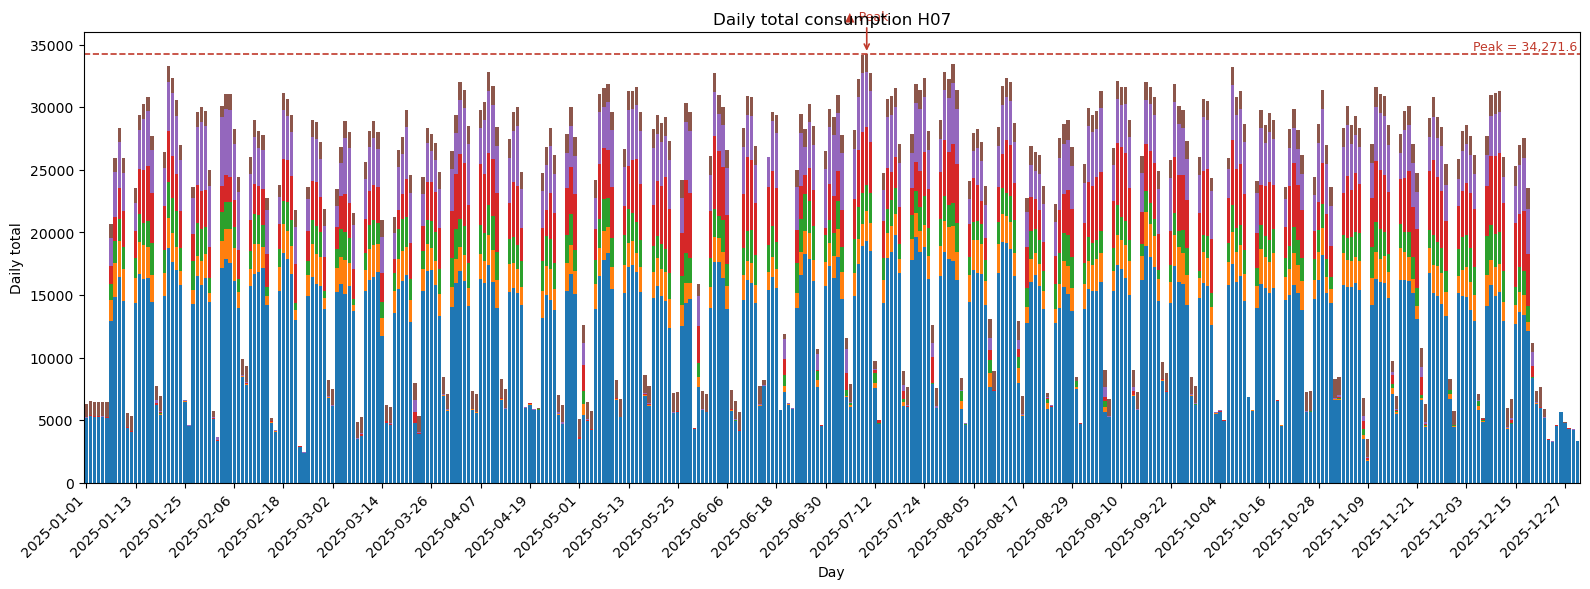

In [62]:
# stacked bar plot
ax = pivot.plot(kind='bar', stacked=True, figsize=(16,6), width=0.8)
ax.set_xlabel('Day')
ax.set_ylabel('Daily total')
ax.set_title(f'Daily total consumption H07')

# show fewer x-ticks for readability
n = len(pivot)
step = max(1, n // 30)
ax.set_xticks(range(0, n, step))
ax.set_xticklabels([pivot.index[i].isoformat() for i in range(0, n, step)], rotation=45, ha='right')

# peak day detection 
row_totals = pivot.sum(axis=1)
peak_idx = row_totals.values.argmax()       
peak_day = pivot.index[peak_idx]
peak_value = row_totals.iloc[peak_idx]

print(f"Peak day: {peak_day.isoformat()}  ->  {peak_value:,.1f}")

DANGER = "#c0392b"

ax.axhline(peak_value, linestyle='--', color=DANGER, linewidth=1.2)
ax.text(
    n-1, peak_value, f'Peak = {peak_value:,.1f}',
    color=DANGER, va='bottom', ha='right', fontsize=9,
)
ax.annotate(
    '▲ Peak',
    xy=(peak_idx, peak_value),
    xytext=(peak_idx, peak_value + row_totals.max() * 0.08),
    ha='center', color=DANGER, fontsize=9,
    arrowprops=dict(arrowstyle='->', color=DANGER, lw=1.2),
)

ax.get_legend().remove()
plt.tight_layout()
plt.show()

### Q2: which machine (meter_id) contributed most on that day?

In [54]:
top_5_meter_df = con.execute(f"""
    SELECT
        f.meter_id,
        COALESCE(d.meter_name, f.meter_id) AS meter_name,
        SUM(f.value)                       AS total_consumption
    FROM fact_measurement_df f
    LEFT JOIN dim_meter d ON f.meter_id = d.meter_id
    WHERE f.hall_id = '{HALL_ID}' AND f.timestamp::DATE = '2025-07-10'
    GROUP BY f.meter_id, d.meter_name
    ORDER BY total_consumption DESC
    LIMIT 5
""").fetchdf()

top_5_meter_df.head(20)

,meter_id,meter_name,total_consumption
0,h07_z_1719_bereich_walzen,Z 1719 Bereich Walzen,4598.994817
1,h07_z_1721_bereich_walzen,Z 1721 Bereich Walzen,4403.991844
2,h07_z_1722_uv7m4_f13_stromschi,Z 1722 UV7M4-F13 (Stromschiene 14),2462.073278
3,h07_z_1717_bereich_pressen,Z 1717 Bereich Pressen,2389.142951
4,h07_z_1718_bereich_pressen,Z 1718 Bereich Pressen,2079.578715


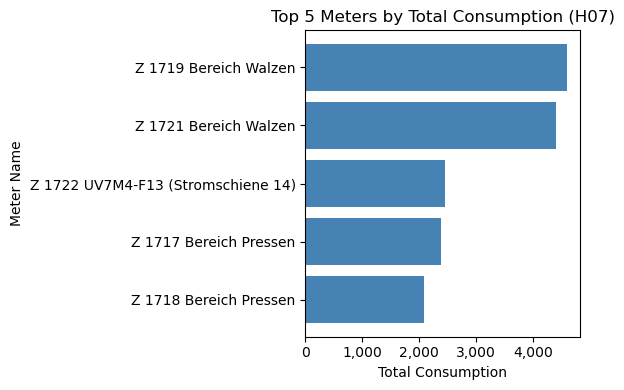

In [55]:
# Create a horizontal bar chart for the top 5 meters
fig, ax = plt.subplots(figsize=(6,4))
ax.barh(top_5_meter_df['meter_name'], top_5_meter_df['total_consumption'], color='steelblue')
ax.set_xlabel('Total Consumption')
ax.set_ylabel('Meter Name')
ax.set_title('Top 5 Meters by Total Consumption (H07)')
ax.invert_yaxis() 

# Format x-axis with thousands separator
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

### Q3: which time interval was the peak for that machine on that day?

In [56]:
peak_interval_df = con.execute(f"""
     SELECT
            f.timestamp AS timestamp,
            f.value     AS consumption
    FROM fact_measurement_df f
    WHERE f.hall_id = '{HALL_ID}' AND f.meter_id = '{top_5_meter_df.iloc[0]['meter_id']}' AND f.value > 0 AND f.timestamp::DATE = '{peak_day}'
    ORDER BY f.timestamp
""").fetchdf()

print(len(peak_interval_df))
peak_interval_df.head(10)

96


,timestamp,consumption
0,2025-07-10 00:14:00+02:00,60.159988
1,2025-07-10 00:29:00+02:00,58.014254
2,2025-07-10 00:44:00+02:00,62.456719
3,2025-07-10 00:59:00+02:00,61.301859
4,2025-07-10 01:14:00+02:00,62.371527
5,2025-07-10 01:29:00+02:00,65.944750
6,2025-07-10 01:44:00+02:00,58.899375
7,2025-07-10 01:59:00+02:00,63.021879
8,2025-07-10 02:14:00+02:00,58.816625
9,2025-07-10 02:29:00+02:00,54.832887


In [57]:
step = peak_interval_df["timestamp"].diff().mode()
step = step.iloc[0] if not step.empty else pd.Timedelta(minutes=15) 
peak_row = peak_interval_df.loc[peak_interval_df["consumption"].idxmax()]
peak_start = peak_row["timestamp"]
peak_end = peak_start + step
peak_val = float(peak_row["consumption"])

print(f"Peak interval: {peak_start} -> {peak_end}  ({peak_val:,.2f} kW)")

Peak interval: 2025-07-10 03:29:00+02:00 -> 2025-07-10 03:44:00+02:00  (69.01 kW)
